# Transfer learning notebook for fingerprintvalidator project

## Project Pre-requisites

In [119]:
# Import libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

In [120]:
# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le transfer learning en computer vision !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.16.2
  - Keras      : 3.13.2
  - NumPy      : 1.26.4

🚀 Prêt pour le transfer learning en computer vision !


## Project Constants

In [121]:
# Random seeding 
TENSORFLOW_SEED = 42
tf.random.set_seed(TENSORFLOW_SEED)

NUMPY_SEED = 42
np.random.seed(NUMPY_SEED)

# Dataset configuration
# True : consider both "Real" and "Altered" subdirectories
# False : consider only "Real" subdirectory (smaller dataset, faster processing)
CONSIDER_FULL_DATASET = False

if CONSIDER_FULL_DATASET:
    DATASET_ROOTDIR_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized" 
    print(f"📁 Fingerprints dataset images root directory path : {DATASET_ROOTDIR_PATH}")

    DATASET_CSV_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized_with_labels.csv"
    print(f"📁 Fingerprints dataset CSV path : {DATASET_CSV_PATH}")
else:
    DATASET_ROOTDIR_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized" 
    print(f"📁 Fingerprints dataset images root directory path : {DATASET_ROOTDIR_PATH}")

    DATASET_CSV_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized_with_labels.csv"
    print(f"📁 Fingerprints dataset CSV path : {DATASET_CSV_PATH}")

class_names = ['thumb', 'index', 'middle', 'ring', 'little']
num_classes = len(class_names)
print(f"\n👁️ fingerprints classes : {class_names}")

📁 Fingerprints dataset images root directory path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized
📁 Fingerprints dataset CSV path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized_with_labels.csv

👁️ fingerprints classes : ['thumb', 'index', 'middle', 'ring', 'little']


## Dataset Exploration

In [122]:
# load csv
df = pd.read_csv(DATASET_CSV_PATH)

print(f"\n📊 Fingerprints dataset basic stats :")
df.info()


📊 Fingerprints dataset basic stats :
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         6000 non-null   int64
 1   ImagePath  6000 non-null   str  
 2   Finger     6000 non-null   str  
dtypes: int64(1), str(2)
memory usage: 140.8 KB


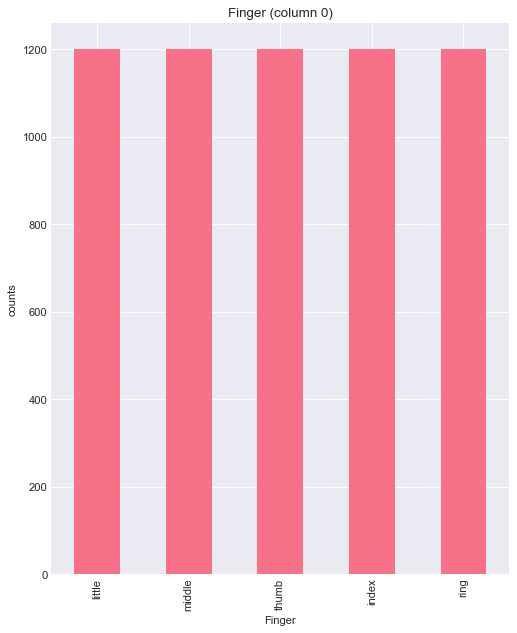

In [123]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

# show distribution of columns
plotPerColumnDistribution(df, 10, 5)

In [124]:
# Display of number of thumbs, index, middle, ring, and little fingers
print(f"Percentage of Thumbs: {df['Finger'].value_counts().get('thumb', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Index fingers: {df['Finger'].value_counts().get('index', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Middle fingers: {df['Finger'].value_counts().get('middle', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Ring fingers: {df['Finger'].value_counts().get('ring', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Little fingers: {df['Finger'].value_counts().get('little', 0) / len(df) * 100:.2f}%")

Percentage of Thumbs: 20.00%
Percentage of Index fingers: 20.00%
Percentage of Middle fingers: 20.00%
Percentage of Ring fingers: 20.00%
Percentage of Little fingers: 20.00%


In [125]:
# List to store file information
imgdata = []

# Traverse the input directory to get all image files
for dirname, _, filenames in os.walk(DATASET_ROOTDIR_PATH):
    for filename in filenames:
         
        if filename == ".DS_Store":  # Skip macOS system files
            continue

        file_path = os.path.join(dirname, filename)

        # extract the image features
        img = Image.open(file_path)
    
        try:
            img.verify()  # Verify that the file is a valid image
        except:
            print(f"Invalid image file: {file_path}")
            continue

        imgdata.append([file_path, img.format, img.size, img.mode])

# Create a DataFrame
imgdf = pd.DataFrame(imgdata, columns=["ImagePath", "ImageFormat", "ImageSize", "ImageMode"])

# Add an index column
imgdf.index.name = "ID"

In [126]:
# display the dataframe info
imgdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ImagePath    6000 non-null   str   
 1   ImageFormat  6000 non-null   str   
 2   ImageSize    6000 non-null   object
 3   ImageMode    6000 non-null   str   
dtypes: object(1), str(3)
memory usage: 187.6+ KB


In [127]:
# Display the distribution of ImageFormat, ImageSize, ImageMode
print(imgdf["ImageFormat"].value_counts())
print(imgdf["ImageSize"].value_counts())
print(imgdf["ImageMode"].value_counts())

ImageFormat
JPEG    6000
Name: count, dtype: int64
ImageSize
(96, 96)    6000
Name: count, dtype: int64
ImageMode
RGB    6000
Name: count, dtype: int64


FingerPrint Examples from dataset



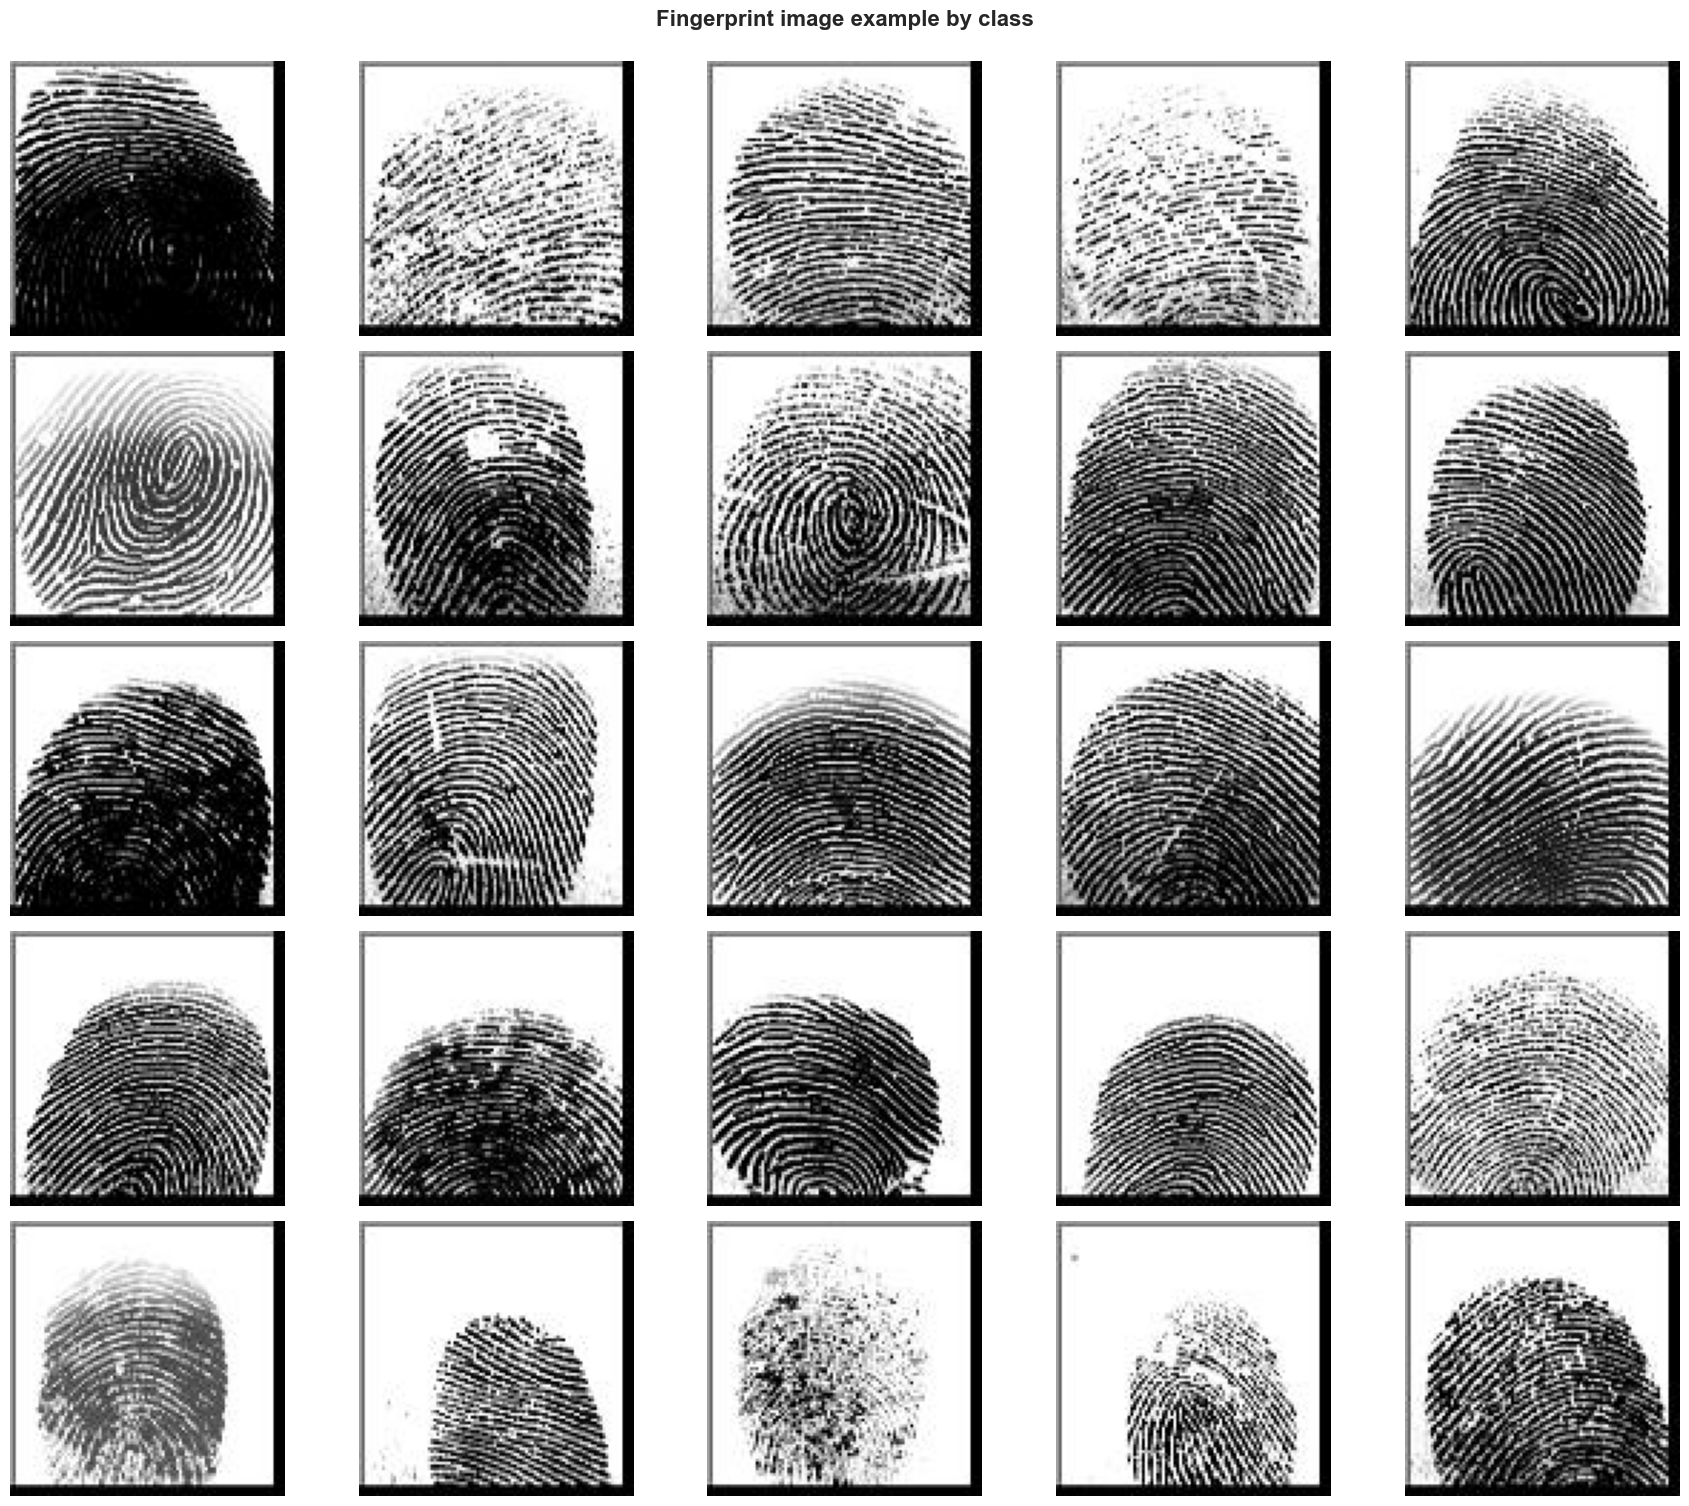

In [128]:
# visualisation of some images
print("FingerPrint Examples from dataset\n")

fig, axes = plt.subplots(num_classes, 5, figsize=(18, 3 * num_classes))

for i, class_name in enumerate(class_names):
    class_path = Path(os.path.join(DATASET_ROOTDIR_PATH, class_name))
    image_files = list(class_path.glob('*.jpeg'))[:5]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.suptitle("Fingerprint image example by class", fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

## Define datasets for training / validation 

In [129]:
print("🔧 Datasets preparation ...\n")

# Dataset parameters
BATCH_SIZE = 32
IMAGE_SIZE = (96, 96)
VALIDATION_SPLIT = 0.3
DATASET_SEED = 42

# Create traning dataset with class filtering
train_ds = image_dataset_from_directory(
    DATASET_ROOTDIR_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=DATASET_SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # One-hot encoding for multi-class
    class_names=class_names  # Explicitly specify the class names to ensure correct mapping
)

# Create validation dataset with the same class names to ensure correct mapping
val_ds = image_dataset_from_directory(
    DATASET_ROOTDIR_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=DATASET_SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names  # Same order of classes
)

print(f"✅ Datasets created !\n")

print(f"📊 Training and validation datasets information:")
print(f"  - Training Dataset Classes             : {train_ds.class_names}")
print(f"  - Validation Dataset Classes           : {val_ds.class_names}")

# Checking number of classes in both datasets
if len(train_ds.class_names) != 5:
    print(f"\n⚠️  ERREUR : {len(train_ds.class_names)} classes détectées au lieu de 5 !")
    print(f"   Classes trouvées : {train_ds.class_names}\n")
elif len(val_ds.class_names) != 5:
    print(f"\n⚠️  ERREUR : {len(val_ds.class_names)} classes détectées au lieu de 5 !")
    print(f"   Classes trouvées : {val_ds.class_names}")
else:
    print(f"  - ✅ Nombre de classes correct : 5\n")

print(f"  - Training batches    : {len(train_ds)}")
print(f"  - Validation batches    : {len(val_ds)}")
print(f"  - Batch size            : {BATCH_SIZE}")
print(f"  - Image size            : {IMAGE_SIZE}\n")
print(f"  - Training samples      : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Validation samples    : ~{len(val_ds) * BATCH_SIZE}")

🔧 Datasets preparation ...

Found 6000 files belonging to 5 classes.
Using 4200 files for training.
Found 6000 files belonging to 5 classes.
Using 1800 files for validation.
✅ Datasets created !

📊 Training and validation datasets information:
  - Training Dataset Classes             : ['thumb', 'index', 'middle', 'ring', 'little']
  - Validation Dataset Classes           : ['thumb', 'index', 'middle', 'ring', 'little']
  - ✅ Nombre de classes correct : 5

  - Training batches    : 132
  - Validation batches    : 57
  - Batch size            : 32
  - Image size            : (96, 96)

  - Training samples      : ~4224
  - Validation samples    : ~1824


## Dataset preparation : normalisation and shuffling only, no augmentation

In [130]:
print("🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...\n")

# Dataset normalisation required for MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Dataset preparation function
def prepare_dataset(ds, augment=False, shuffle=True):

    # Normalisation MobileNetV2
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle (training only)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    
    # Performances optimisation
    ds = ds.cache()  # Memory caching
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch for acceleration
    
    return ds

# Apply transformations
train_ds_prepared = prepare_dataset(train_ds, augment=False, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, augment=False, shuffle=False)

print("✅ Dataset preparation completed !\n")

print("📝 Applied transformations :")
print("  - Training dataset   : normalisation + shuffle")
print("  - Validation dataset : Normalisation")
print("\n  - Caching et prefetch activated for performance")

🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...

✅ Dataset preparation completed !

📝 Applied transformations :
  - Training dataset   : normalisation + shuffle
  - Validation dataset : Normalisation

  - Caching et prefetch activated for performance


## Construct FingerPrint Model : Pre-trained MobileNetV2 + finger classifier

In [131]:
# Constants for the model
INPUT_SHAPE = (96, 96, 3)
NUM_CLASSES = 5
HIDDEN_DENSE_LAYER_SIZE = 256

DROPOUT_RATE = 0.3
L2_REGULARIZATION = 0.01
LEARNING_RATE = 0.001

In [132]:
print("📥 Loading MobileNetV2 ...")

# Loading pre-trained MobileNetV2 without the classifier (include_top=False)
# We will add our own classifier for finger classification
base_mobilenet_model = MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,  # Exclure la couche de classification ImageNet
    weights='imagenet',  # Load pre-trained weights from ImageNet
    pooling='avg'  # Global Average Pooling to end model
)

print("✅ MobileNetV2 model loaded !\n")

# Display model structure
print("📋 Model Structure - MobileNetV2 :")
print(f"  - Architecture   : MobileNetV2")
print(f"  - Input shape    : {INPUT_SHAPE}")
print(f"  - Weights        : ImageNet (1000 classes)")
print(f"  - Output shape   : {base_mobilenet_model.output_shape}")
print(f"  - Number of layers : {len(base_mobilenet_model.layers)}")

# Count parameters
total_params = base_mobilenet_model.count_params()
print(f"\n  - Total number of parameters : {total_params:,}")
print(f"  - Memory size (approx.) : {total_params * 4 / (1024**2):.1f} MB")

print("\n💡 This model has already been trained on 1.4 million images !")
print("   We will now adapt it to our finger classification task.")

📥 Loading MobileNetV2 ...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 model loaded !

📋 Model Structure - MobileNetV2 :
  - Architecture   : MobileNetV2
  - Input shape    : (96, 96, 3)
  - Weights        : ImageNet (1000 classes)
  - Output shape   : (None, 1280)
  - Number of layers : 155

  - Total number of parameters : 2,257,984
  - Memory size (approx.) : 8.6 MB

💡 This model has already been trained on 1.4 million images !
   We will now adapt it to our finger classification task.


In [133]:
print("🧊 Construct model with classifier...\n")

# Freeze the base model to keep the pre-trained features
base_mobilenet_model.trainable = False

print(f"✅ Base model frozen")
print(f"   {len(base_mobilenet_model.layers)} layers not trainable\n")

# OPTIMAL Architecture for this dataset
inputs = keras.Input(shape=INPUT_SHAPE)
x = base_mobilenet_model(inputs, training=False)

# Classifier with regularizerization 
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(HIDDEN_DENSE_LAYER_SIZE, activation='relu', kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

fingerprint_frozen_model = keras.Model(inputs, outputs, name='MobileNetV2_FingerPrint')

# Compiler avec LR optimal
fingerprint_frozen_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),  # LR standard
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled !\n")

print("📊 Architecture MobileNetV2 FingerPrint:")
print(f"  Input{INPUT_SHAPE} → MobileNetV2 → Dropout({DROPOUT_RATE}) → Dense(256,relu) → Dropout({DROPOUT_RATE}) → Dense({NUM_CLASSES},softmax)\n")

trainable = sum([tf.size(w).numpy() for w in fingerprint_frozen_model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in fingerprint_frozen_model.non_trainable_weights])
print(f"  - Trainable parameters     : {trainable:,}")
print(f"  - Non-trainable parameters : {non_trainable:,}")
print(f"  - Total                    : {trainable + non_trainable:,}")

print("\n💡 Model configuration :")
print(f"  - Learning rate      : {LEARNING_RATE} (standard)")
print(f"  - Dropout rate       : {DROPOUT_RATE} (medium)")
print(f"  - Hidden dense layer : {HIDDEN_DENSE_LAYER_SIZE} neurons")
print(f"  - L2 regularization  : {L2_REGULARIZATION}")

🧊 Construct model with classifier...

✅ Base model frozen
   155 layers not trainable

✅ Model compiled !

📊 Architecture MobileNetV2 FingerPrint:
  Input(96, 96, 3) → MobileNetV2 → Dropout(0.3) → Dense(256,relu) → Dropout(0.3) → Dense(5,softmax)

  - Trainable parameters     : 329,221
  - Non-trainable parameters : 2,257,984
  - Total                    : 2,587,205

💡 Model configuration :
  - Learning rate      : 0.001 (standard)
  - Dropout rate       : 0.3 (medium)
  - Hidden dense layer : 256 neurons
  - L2 regularization  : 0.01


## Display FingerPrint Model

In [134]:
print("🔍 Visualizing MobileNetV2 model\n")
print("="*80)

def get_output_shape(layer):
    try:
        if hasattr(layer, 'output_shape'):
            return str(layer.output_shape)
        elif hasattr(layer, 'output'):
            return str(layer.output.shape)
        else:
            return "N/A"
    except:
        return "N/A"

# Display the first 10 and last 10 layers of the base model to understand the feature extraction process
print("\n📌 First layers (low-level feature extraction) :")
for i, layer in enumerate(base_mobilenet_model.layers[:10]):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n      ...")

print("\n📌 Last layers (high-level features) :")
for i, layer in enumerate(base_mobilenet_model.layers[-10:], start=len(base_mobilenet_model.layers)-10):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n" + "="*80)

🔍 Visualizing MobileNetV2 model


📌 First layers (low-level feature extraction) :
    1. input_layer_17                           | Output: (None, 96, 96, 3)              | Trainable: False
    2. Conv1                                    | Output: (None, 48, 48, 32)             | Trainable: False
    3. bn_Conv1                                 | Output: (None, 48, 48, 32)             | Trainable: False
    4. Conv1_relu                               | Output: (None, 48, 48, 32)             | Trainable: False
    5. expanded_conv_depthwise                  | Output: (None, 48, 48, 32)             | Trainable: False
    6. expanded_conv_depthwise_BN               | Output: (None, 48, 48, 32)             | Trainable: False
    7. expanded_conv_depthwise_relu             | Output: (None, 48, 48, 32)             | Trainable: False
    8. expanded_conv_project                    | Output: (None, 48, 48, 16)             | Trainable: False
    9. expanded_conv_project_BN                 | Outp

In [135]:
print("🔍 Visualizing FingerPrint (frozen) model architecture")
print("="*55)

fingerprint_frozen_model.summary()

🔍 Visualizing FingerPrint (frozen) model architecture


Model: "MobileNetV2_FingerPrint"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training FingerPrint model

In [136]:
# Constants for training callbacks
EARLYSTOPPING_PATIENCE = 10
EARLYSTOPPING_VERBOSE = 1

REDUCELRONPLATEAU_FACTOR = 0.5
REDUCELRONPLATEAU_PATIENCE = 4
REDUCELRONPLATEAU_MIN_LR = 1e-7
REDUCELRONPLATEAU_VERBOSE = 1

MODELCHECKPOINT_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/models/best_fingerprint_frozen_model.keras"
MODELCHECKPOINT_VERBOSE = 1

FIT_NUM_EPOCHS = 30
FIT_VERBOSE = 1

In [137]:
# Training function
def fit_fingerprint_model(model: keras.Model, train_ds: tf.data.Dataset, val_ds: tf.data.Dataset):

    print("🚀 Training (frozen) FingerPrint model ...\n")

    # Define callbacks
    early_stopping = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=EARLYSTOPPING_PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=EARLYSTOPPING_VERBOSE
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=REDUCELRONPLATEAU_FACTOR,
        patience=REDUCELRONPLATEAU_PATIENCE,
        min_lr=REDUCELRONPLATEAU_MIN_LR,
        verbose=REDUCELRONPLATEAU_VERBOSE
    )

    checkpoint = callbacks.ModelCheckpoint(
        MODELCHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=MODELCHECKPOINT_VERBOSE
    )

    print(f"Configuration :")
    print(f"  - Maximum Number of Epochs : {FIT_NUM_EPOCHS}")
    print(f"  - EarlyStopping Patience   : {EARLYSTOPPING_PATIENCE} epochs")
    print(f"  - Reduce LR Patience       : {REDUCELRONPLATEAU_PATIENCE} epochs")
    print(f"  - LR initial               : {LEARNING_RATE}")
    print(f"  - LR min                  : {REDUCELRONPLATEAU_MIN_LR}\n")
    
    history_fit = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FIT_NUM_EPOCHS,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        verbose=FIT_VERBOSE
    )
    
    print("\n✅ Fingerprint (frozen) model training completed !")
    print(f"   Epochs completed : {len(history_fit.history['loss'])}")
    
    best_val_acc = max(history_fit.history['val_accuracy'])
    best_epoch = history_fit.history['val_accuracy'].index(best_val_acc) + 1
    print(f"   Best val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

    if best_val_acc < 0.70:
        print(f"\n⚠️  Accuracy of {best_val_acc*100:.1f}% is below 70%")
        print("   The model could benefit from more training.")
    elif best_val_acc < 0.80:
        print(f"\n✅ Good result : {best_val_acc*100:.1f}%")
    else:
        print(f"\n🎯 Excellent ! Accuracy of {best_val_acc*100:.1f}%")


## First model training 

In [138]:
# initial training with frozen base model
fit_fingerprint_model(fingerprint_frozen_model, train_ds_prepared, val_ds_prepared)

🚀 Training (frozen) FingerPrint model ...

Configuration :
  - Maximum Number of Epochs : 30
  - EarlyStopping Patience   : 10 epochs
  - Reduce LR Patience       : 4 epochs
  - LR initial               : 0.001
  - LR min                  : 1e-07

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3905 - loss: 5.2163
Epoch 1: val_accuracy improved from None to 0.56611, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/best_fingerprint_frozen_model.keras

Epoch 1: finished saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/best_fingerprint_frozen_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.4217 - loss: 4.1999 - val_accuracy: 0.5661 - val_loss: 2.2866 - learning_rate: 0.0010
Epoch 2/30
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4522 - loss: 2.7149
Epoch 2: val_accuracy improved from 0.56611 to 0.58389, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/best_fi

## Second training of frozen base model

In [139]:
# increase num epochs and patience parameters
FIT_NUM_EPOCHS = 50
EARLYSTOPPING_PATIENCE = 20
REDUCELRONPLATEAU_PATIENCE = 10

fit_fingerprint_model(fingerprint_frozen_model, train_ds_prepared, val_ds_prepared)

🚀 Training (frozen) FingerPrint model ...

Configuration :
  - Maximum Number of Epochs : 50
  - EarlyStopping Patience   : 20 epochs
  - Reduce LR Patience       : 10 epochs
  - LR initial               : 0.001
  - LR min                  : 1e-07

Epoch 1/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5080 - loss: 1.3564
Epoch 1: val_accuracy improved from None to 0.56611, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/best_fingerprint_frozen_model.keras

Epoch 1: finished saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/best_fingerprint_frozen_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5000 - loss: 1.3754 - val_accuracy: 0.5661 - val_loss: 1.1955 - learning_rate: 0.0010
Epoch 2/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5242 - loss: 1.2978
Epoch 2: val_accuracy improved from 0.56611 to 0.58500, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/best_fi